# Credit Risk Modeling

## Exploratory Data Analysis (EDA)

### Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before preprocessing and model building.

In this notebook, we will:

- Analyze numerical and categorical features.
- Explore the distribution of the target variable.
- Visualize important features.
- Identify missing values.
- Detect outliers.
- Study relationships between variables.
- Generate insights that will guide feature selection and preprocessing.

The observations from this notebook will help us build a more reliable machine learning model.

## 1. Import Required Libraries

Before performing Exploratory Data Analysis, we need to import the required Python libraries.

These libraries help us:

- Load and manipulate data.
- Create statistical summaries.
- Generate visualizations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

### Interpretation

The required libraries have been successfully imported.

We are now ready to perform Exploratory Data Analysis.

## 2. Load the Dataset

Load the LendingClub dataset into a Pandas DataFrame for analysis.

In [2]:
df = pd.read_csv("../data/loan.csv", low_memory=False)

## 3. Dataset Overview

Before creating visualizations, let us quickly review the size of the dataset.

In [3]:
print(f"Rows : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows : 2,260,668
Columns : 145


## 4. Analyze Missing Values

Missing values reduce data quality and must be identified before preprocessing.

This analysis helps us determine which columns require cleaning or removal.

In [4]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing.head(20)

id                                            2260668
member_id                                     2260668
url                                           2260668
orig_projected_additional_accrued_interest    2252242
hardship_amount                               2250055
hardship_dpd                                  2250055
hardship_loan_status                          2250055
deferral_term                                 2250055
hardship_end_date                             2250055
hardship_status                               2250055
hardship_start_date                           2250055
hardship_reason                               2250055
hardship_type                                 2250055
hardship_payoff_balance_amount                2250055
hardship_last_payment_amount                  2250055
hardship_length                               2250055
payment_plan_start_date                       2250055
debt_settlement_flag_date                     2227612
settlement_term             

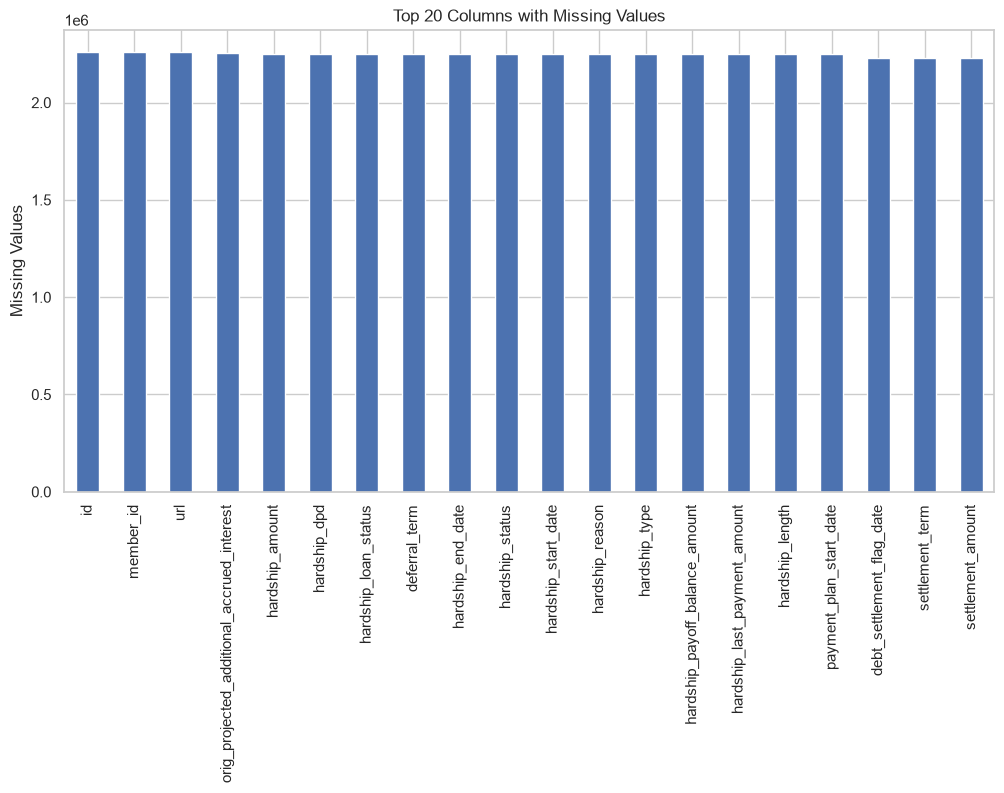

In [5]:
plt.figure(figsize=(12,6))

missing.head(20).plot(kind="bar")

plt.title("Top 20 Columns with Missing Values")

plt.ylabel("Missing Values")

plt.xticks(rotation=90)

plt.show()

### Interpretation

Several features contain a large number of missing values.

Columns with extremely high percentages of missing values may be removed during preprocessing if they do not contribute significantly to prediction.

## 5. Distribution of Loan Status

The target variable is `loan_status`.

Understanding its distribution helps identify whether the dataset is balanced or imbalanced.

In [6]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

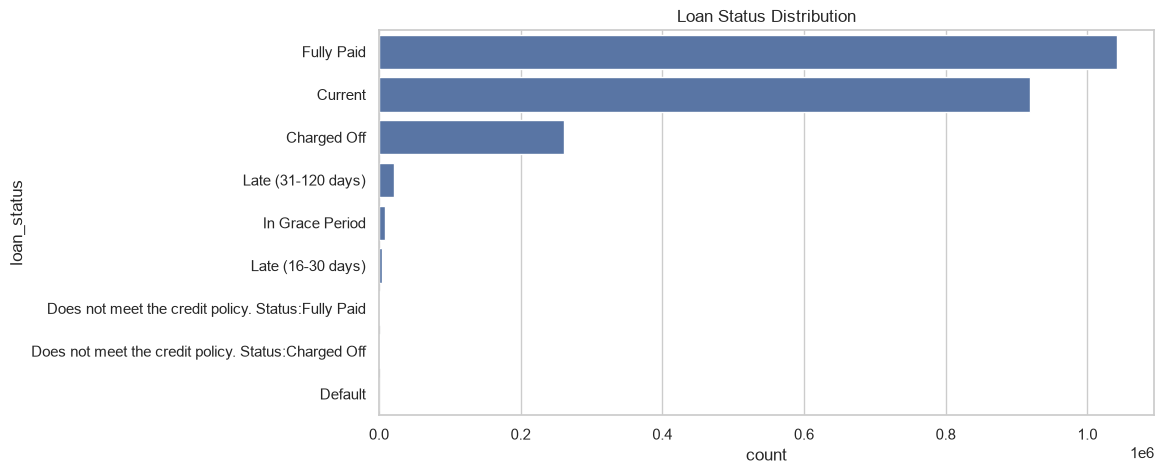

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(y=df["loan_status"],
              order=df["loan_status"].value_counts().index)

plt.title("Loan Status Distribution")

plt.show()

### Interpretation

The target variable contains multiple loan status categories.

Later, suitable categories will be selected for binary classification, and class imbalance will be addressed using SMOTE.

## 6. Numerical Feature Distribution

We now examine important numerical features to understand their distributions.

The selected features include:

- Loan Amount
- Annual Income
- Interest Rate
- Debt-to-Income Ratio

In [8]:
features = [
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "dti"
]

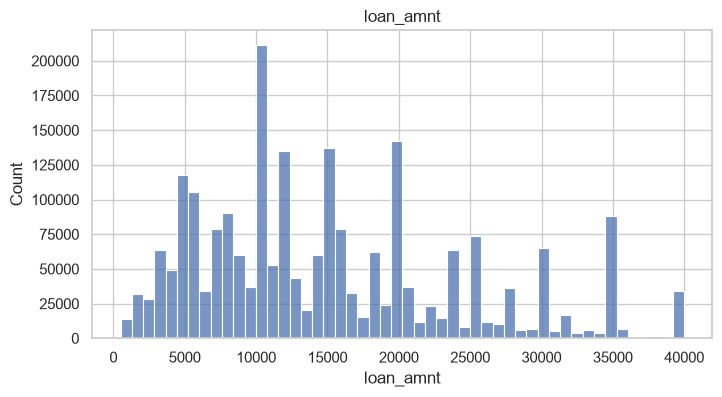

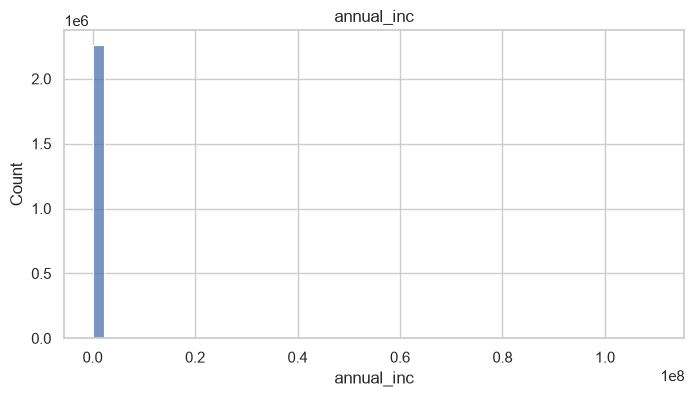

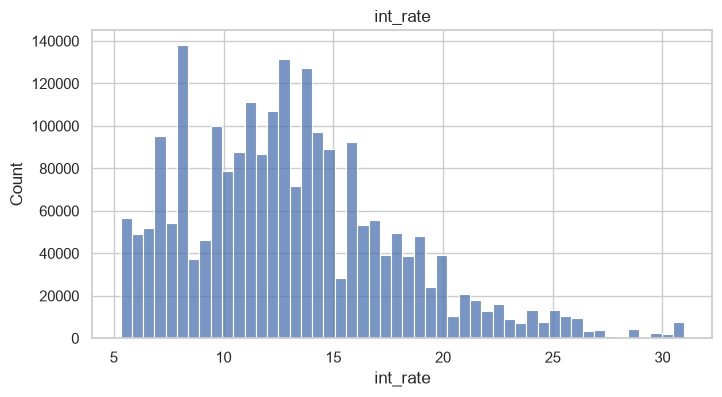

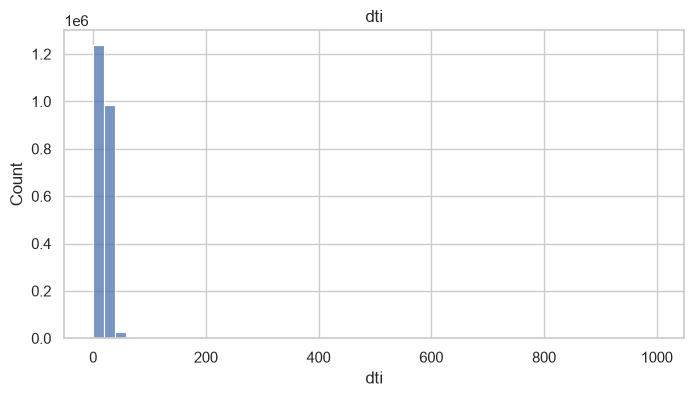

In [9]:
for col in features:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], bins=50)

    plt.title(col)

    plt.show()

### Interpretation

These plots help us understand:

- Feature distribution
- Presence of skewness
- Extreme values
- Possible outliers

These observations will help determine whether transformations are required during preprocessing.

## 7. Detect Outliers

Boxplots help identify extreme values in numerical features.

Outliers are common in financial datasets and should be analyzed carefully before deciding whether to remove or retain them.

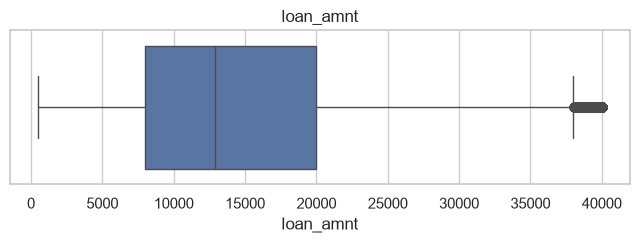

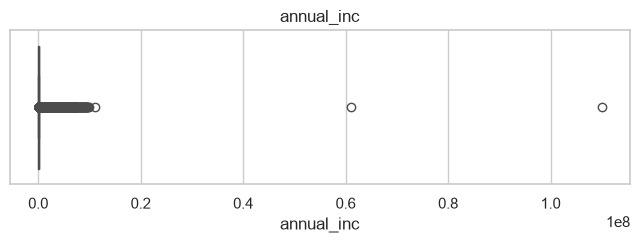

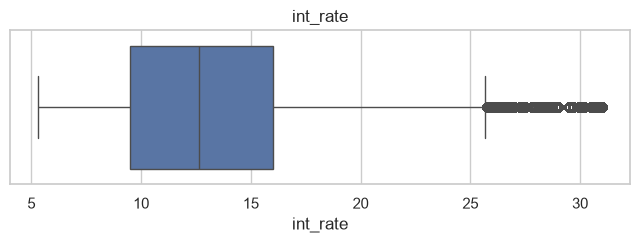

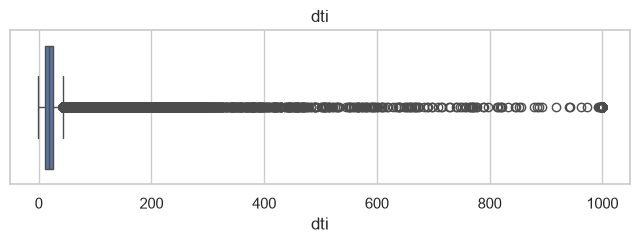

In [10]:
for col in features:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

### Interpretation

Several numerical features contain outliers.

Since financial datasets naturally contain customers with very high income or large loans, these values should not be removed without proper analysis.

## 8. Categorical Feature Analysis

Categorical variables contain labels instead of numbers.

Understanding their distributions helps identify dominant categories.

In [11]:
categorical = [

    "term",

    "grade",

    "home_ownership",

    "verification_status",

    "purpose"

]

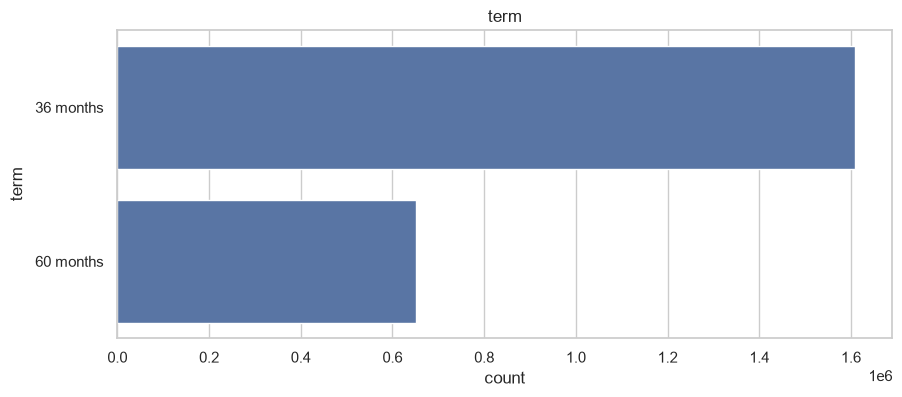

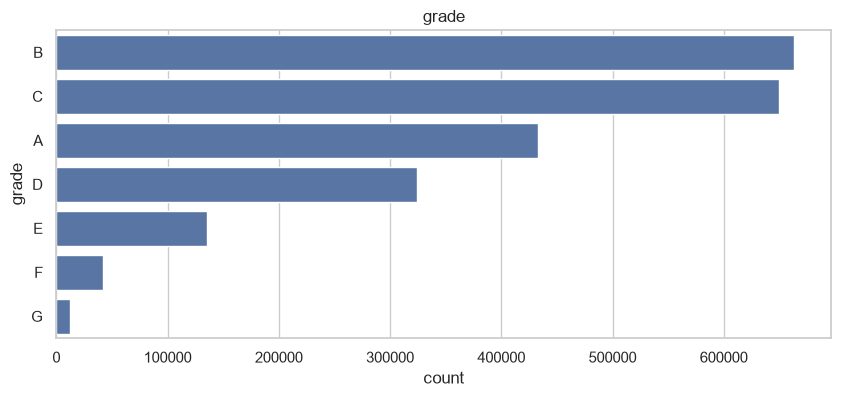

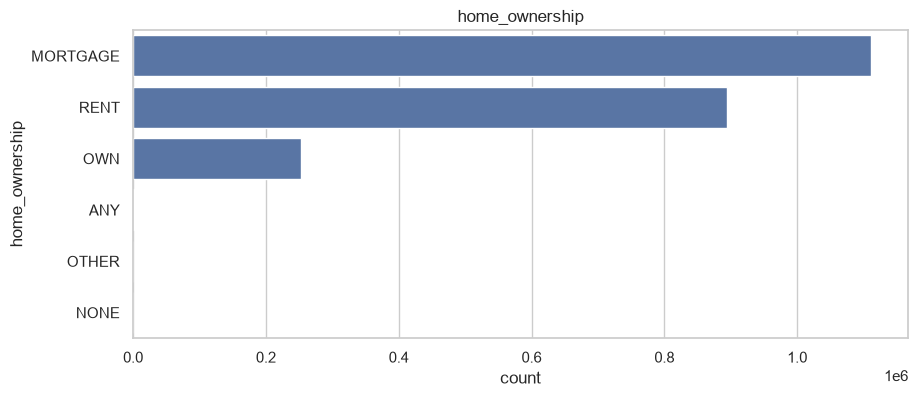

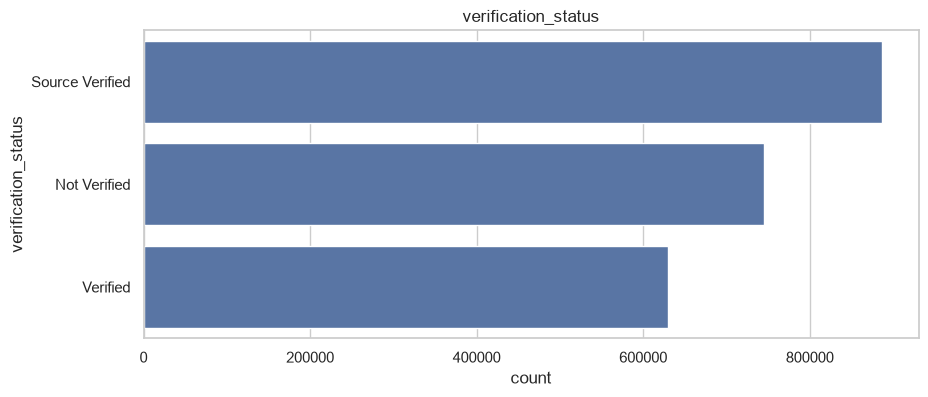

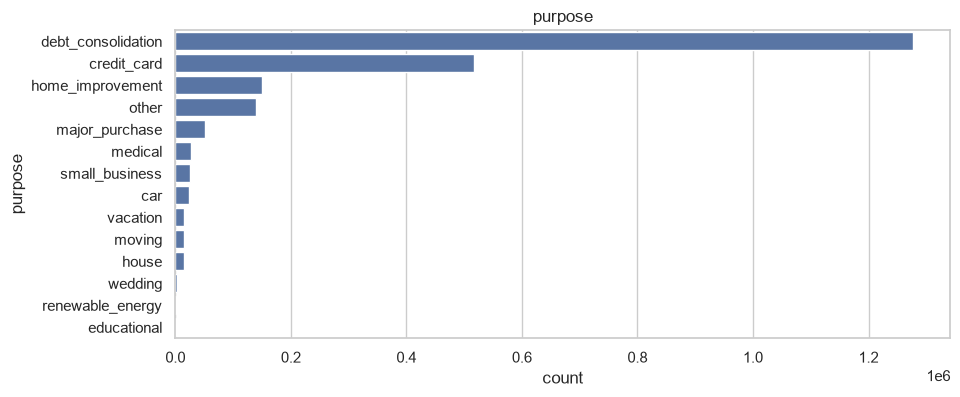

In [12]:
for col in categorical:

    plt.figure(figsize=(10,4))

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index
    )

    plt.title(col)

    plt.show()

### Interpretation

Categorical variables contain multiple classes.

These variables will later be converted into numerical representations using suitable encoding techniques.

## 9. Correlation Analysis

Correlation measures the relationship between numerical variables.

Highly correlated variables may contain similar information and can influence feature selection.

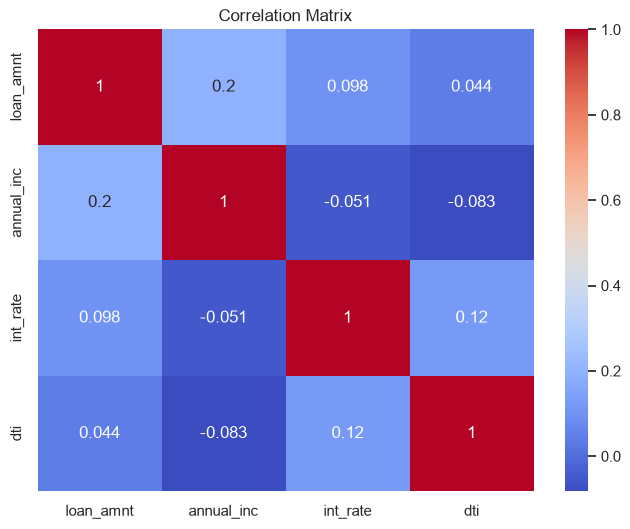

In [13]:
corr = df[features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The correlation matrix helps identify relationships between numerical variables.

Strong positive or negative correlations may be useful during feature selection.

## 10. Loan Amount by Loan Status

This visualization helps us understand whether loan amount differs across loan status categories.

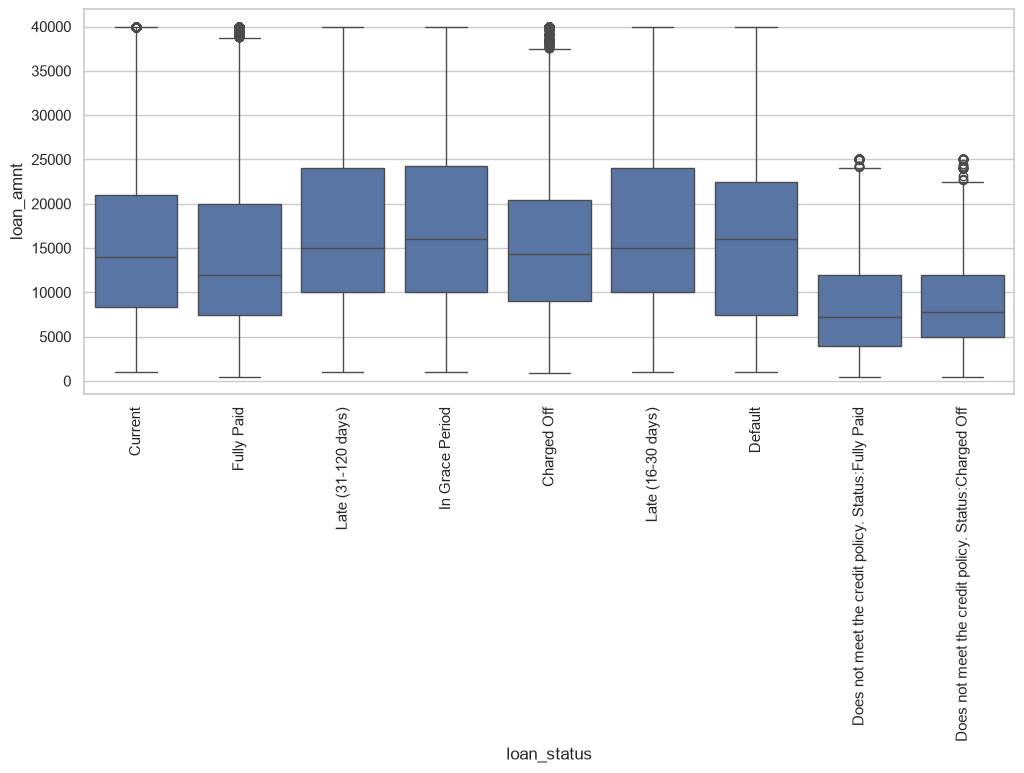

In [14]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x="loan_status",
    y="loan_amnt",
    data=df
)

plt.xticks(rotation=90)

plt.show()

### Interpretation

Comparing loan amount across different loan statuses provides insight into whether larger loans are associated with increased repayment risk.

This relationship will be explored further during model development.

# Final Observations

Key findings from the Exploratory Data Analysis:

- The dataset contains several missing values.
- The target variable contains multiple categories.
- Numerical variables exhibit skewness and outliers.
- Financial variables such as annual income and loan amount have wide value ranges.
- Categorical variables contain multiple unique classes.
- Feature engineering and preprocessing will be required before model training.

These findings will guide the preprocessing steps in the next notebook.